<a href="https://colab.research.google.com/github/Shlokp2024/Certificates/blob/main/Plant_Disease_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/My Drive/FSWD/Data/Plant_images_pianalytix/Potato"

'b475147c-92bc-419a-b2c3-7d5aabbb79ec___RS_Early.B 7379.JPG'
'b6220993-c51f-48fa-bee9-fb5cb89cc0c4___RS_Early.B 7467.JPG'
'b7157976-61c2-4366-87c5-e3de23aa7c10___RS_Early.B 7227.JPG'
'b7883606-5157-4dc1-b965-fc10f8fe1796___RS_Early.B 7598.JPG'
'b817817e-a6b1-4123-88e7-db98b453ce17___RS_Early.B 6880.JPG'
'b8578828-0e34-4511-9739-9ef0170774b2___RS_Early.B 7416.JPG'
'b8803558-9e0f-404e-80b3-c78d0bc7f6d0___RS_Early.B 7548.JPG'
'ba5dfd98-89d6-49d5-b398-beb05cb9d8ad___RS_Early.B 7824.JPG'
'ba96aab6-adb5-4021-b6ad-3305f50aec12___RS_Early.B 7317.JPG'
'bac19c19-ab8b-466a-a317-56c1f35fb082___RS_Early.B 7141.JPG'
'bb07a1b7-b9ad-4016-a013-9ff0e4636d4a___RS_Early.B 7156.JPG'
'bb38077f-ee91-4c0b-af46-f90b21b9e9db___RS_Early.B 7121.JPG'
'bb3d6df0-683e-4f04-afaf-277a36edad6c___RS_Early.B 9070.JPG'
'bb4e9c01-6166-424d-a379-9ef405fdd555___RS_Early.B 6843.JPG'
'bb569e8c-4f57-481f-86d9-291ebd67336e___RS_Early.B 7543.JPG'
'bc378ba0-533d-42db-a8b2-82decc73f4d5___RS_Early.B 9092.JPG'
'bc7552e4-3901-41b8-8bef

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread
import cv2
import random
import os
from os import listdir
from PIL import Image
from sklearn.preprocessing import label_binarize, LabelBinarizer
from keras.preprocessing import image
from keras.preprocessing.image import img_to_array,array_to_img
from keras.optimizers import Adam
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D
from keras.layers import Activation,Flatten,Dropout,Dense
from sklearn.model_selection import train_test_split
from keras.models import model_from_json
from keras.utils import to_categorical

SyntaxError: invalid syntax (<ipython-input-1-d0ab78755178>, line 10)

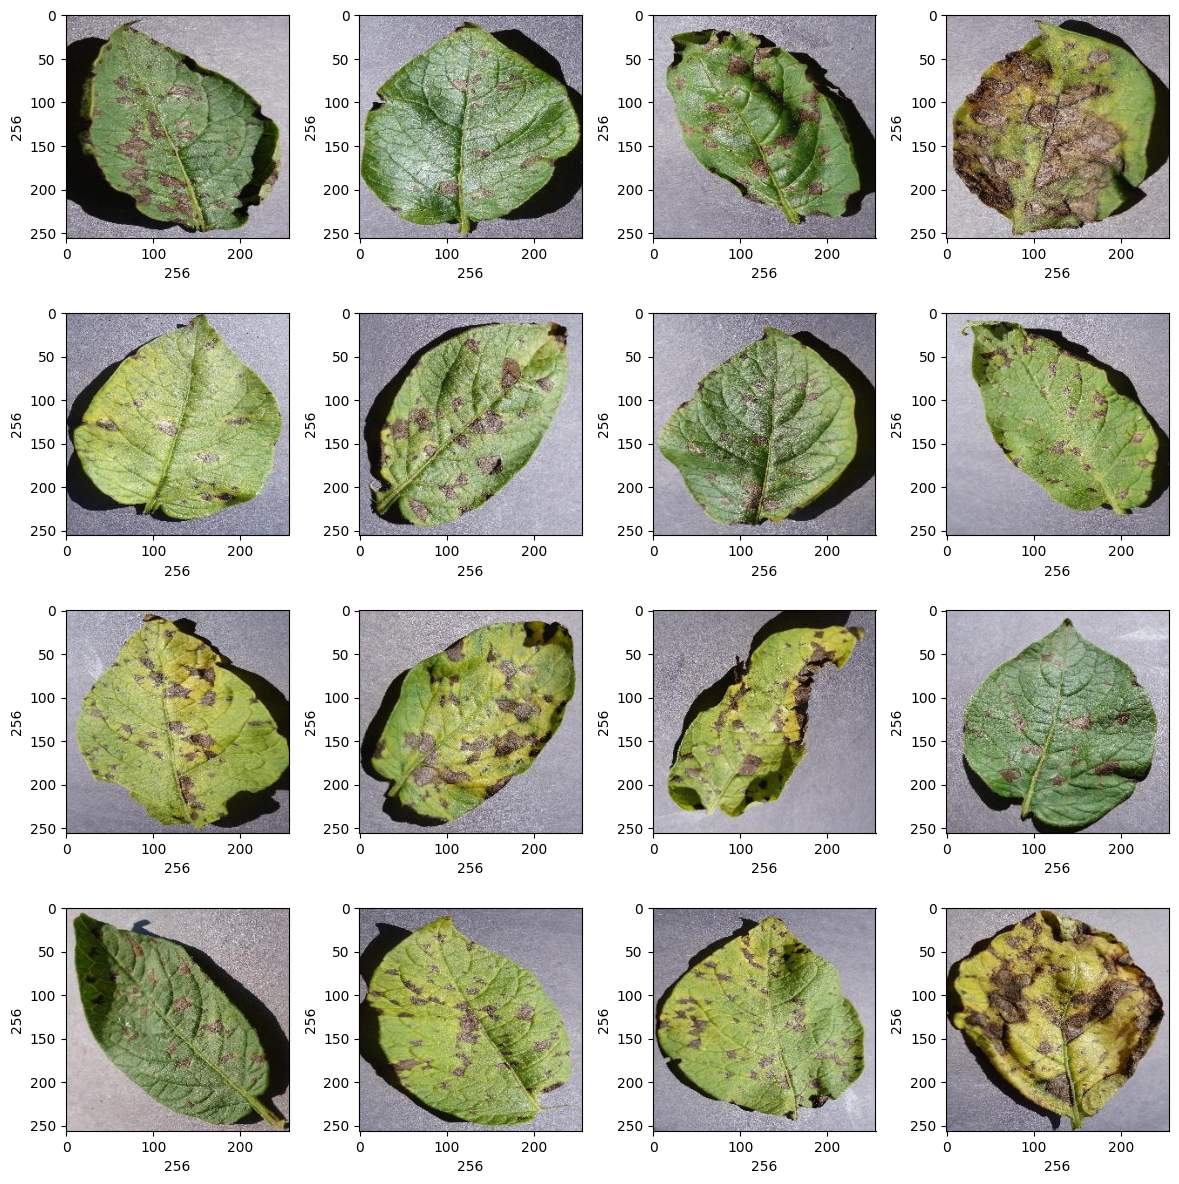

In [ ]:
plt.figure(figsize=(12,12))
path = "/content/drive/MyDrive/FSWD/Data/Plant_images_pianalytix/Potato"
for i in range(1,17):
  plt.subplot(4,4,i);
  plt.tight_layout()
  rand_img = imread(path + '/' + random.choice(sorted(os.listdir(path))))
  plt.imshow(rand_img)
  plt.xlabel(rand_img.shape[1], fontsize=10)
  plt.ylabel(rand_img.shape[0],fontsize=10)

In [ ]:
def convert_image_to_array(image_dir):
  try:
    image = cv2.imread(image_dir)
    if image is not None:
      image = cv2.resize(image,(256,256))
      return img_to_array(image)
    else :
      return np.array([])
  except Exception as e:
    print(f"Errot:{e}")
    return None

In [ ]:
dir = "/content/drive/My Drive/FSWD/Data/Plant_images_pianalytix"
root_dir = listdir(dir)
image_list, label_list = [], []
all_labels = ['Corn_Maize', 'Potato', 'Tomato']
binary_labels = [0,1,2]
temp = -1

for directory in root_dir:
  plant_image_list = listdir (f"{dir}/{directory}")
  temp += 1
  for files in plant_image_list:
    image_path = f"{dir}/{directory}/{files}"
    image_list.append(convert_image_to_array(image_path))
    label_list.append (binary_labels[temp])

In [ ]:
label_counts = pd.DataFrame(label_list).value_counts()
label_counts.head()

0    300
1    300
2    300
Name: count, dtype: int64

In [ ]:
image_list[0].shape

(256, 256, 3)

In [ ]:
label_list = np.array(label_list)
label_list.shape

(900,)

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(image_list,label_list,test_size=0.2,random_state=10)

In [ ]:
x_train = np.array(x_train,dtype=np.float16) / 225.0
x_test = np.array(x_test,dtype=np.float16) / 225.0
x_train = x_train.reshape(-1,256,256,3)
x_test = x_test.reshape(-1,256,256,3)

In [ ]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [ ]:
model = Sequential()
model.add(Conv2D(32,(3,3),padding="same",input_shape=(256,256,3),activation="relu"))
model.add(MaxPooling2D(pool_size=(3,3)))
model.add(Conv2D(64,(3,3),padding="same",activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(64,activation="relu"))
model.add(Dense(3,activation="softmax"))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 256, 256, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 85, 85, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 85, 85, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 42, 42, 64)        0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 112896)            0         
                                                                 
 dense (Dense)               (None, 64)                7

In [ ]:
model.compile(loss='categorical_crossentropy',optimizer=Adam(0.0001),metrics=['accuracy'])

In [ ]:
x_train,x_val,y_train,y_val = train_test_split(x_train,y_train,test_size=0.2)
x_train.shape

(576, 256, 256, 3)

In [ ]:
epochs = 50
batch_size = 128
history = model.fit(x_train,y_train,batch_size = batch_size , epochs = epochs,validation_data = (x_val,y_val))

Epoch 1/50
5/5 [==============================] - 53s 10s/step - loss: 0.9106 - accuracy: 0.5521 - val_loss: 0.5112 - val_accuracy: 0.9653
Epoch 2/50
5/5 [==============================] - 49s 10s/step - loss: 0.4434 - accuracy: 0.8542 - val_loss: 0.2858 - val_accuracy: 0.9792
Epoch 3/50
5/5 [==============================] - 46s 9s/step - loss: 0.2455 - accuracy: 0.9583 - val_loss: 0.1870 - val_accuracy: 0.9514
Epoch 4/50
5/5 [==============================] - 51s 10s/step - loss: 0.1581 - accuracy: 0.9653 - val_loss: 0.1127 - val_accuracy: 0.9861
Epoch 5/50
5/5 [==============================] - 49s 10s/step - loss: 0.1063 - accuracy: 0.9774 - val_loss: 0.0863 - val_accuracy: 0.9931
Epoch 6/50
5/5 [==============================] - 55s 10s/step - loss: 0.0766 - accuracy: 0.9809 - val_loss: 0.0742 - val_accuracy: 0.9722
Epoch 7/50
5/5 [==============================] - 48s 9s/step - loss: 0.0656 - accuracy: 0.9809 - val_loss: 0.0695 - val_accuracy: 0.9792
Epoch 8/50
5/5 [=============

In [ ]:
model.save("/content/drive/My Drive/FSWD/plant_disease.h5")
json_model = model.to_json()
with open('/content/drive/My Drive/FSWD/plant_model.json','w') as json_file:
  json_file.write(json_model)
model.save_weights('/content/drive/My Drive/FSWD/plant_model_weights.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


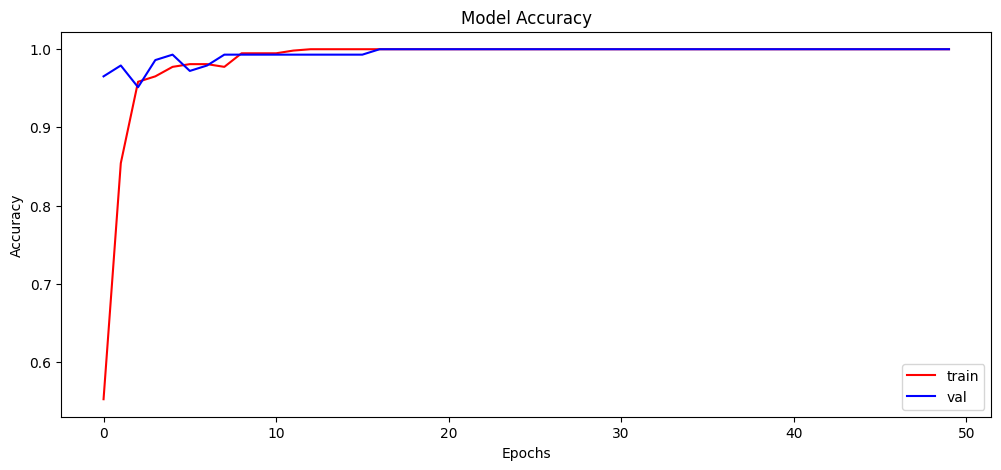

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(history.history['accuracy'],color='r')
plt.plot(history.history['val_accuracy'],color='b')
plt.title('Model Accuracy')
plt.ylabel("Accuracy")
plt.xlabel("Epochs")
plt.legend(['train','val'])
plt.show()

In [ ]:
print("[INFO] Calculating model accuracy")
scores = model.evaluate(x_test,y_test)
print(f"Test Accuracy : {scores[1]*100}")

[INFO] Calculating model accuracy
6/6 [==============================] - 4s 616ms/step - loss: 0.0403 - accuracy: 0.9944
Test Accuracy : 99.44444298744202


In [ ]:
y_pred = model.predict(x_test)

6/6 [==============================] - 6s 916ms/step


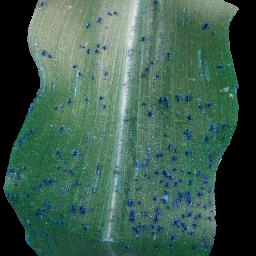

In [ ]:
img = array_to_img(x_test[11])
img

In [ ]:
print("Originally : ",all_labels[np.argmax(y_test[11])])
print("Predicted : ",all_labels[np.argmax(y_pred[11])])

Originally :  Corn_Maize
Predicted :  Corn_Maize
